## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** William Keenan

**Date:** 9/27/2026

1. The difference between regression and classification is the type of outcome that each results in. Both are supervised learning, with regression predicting a numeric, continuous outcome (like a price for a house or a temperature), while classification predicts a categorical outcome. Regression's "how wrong" is a matter of distance, while classification is either in the right or wrong category.

2. A confusion table is a scorecard that compares what the model guessed with what is actually true. The correct guesses sit on the diagonal and everything else is a mistake. Its value is that it shows what kind of mistakes the model makes. "90% accurate" sounds great until the table shows that nearly all the errors happen in one category that you might "care" the most about or is most important.

3. The SSE adds up how far off each prediction was, after squaring each miss. A small SSE meaans that the prediction was pretty close to the real values. Squaring the miss just increases the severity of a large miss, since for example missing by 10 will have an SSE of 100, but missing by 2 will have an SSE of 4.

4. Overfitting is the equivalent of memorizing instead of learning, like a student who memorizes practice answers and fails the real exam because the questions changed. If a model is overfit it is not able to be applied to other datasets accurately. Underfitting is the opposite of this problem - the model is too simply and not developed enough, and is not able to accurately identify real patterns. Keeping with the metaphor, it's like a student who just puts "C" as the answer to every question. A well-developed model sits between overfit and underfit.

5. The reason for splitting data into training and test sets is because if you grade a model on the same data it learned from, it will be the equivalent of taking a test you've already studied for. Hiding some data and allowing the model to run on fresh data will show the accuracy of the model and see how well it can perform. You can also try different values of k and keep the one that scores best on the test set.

6. For class labels vs probability distributions, a single label is simple and actionable. It's easy to communicate, easy to evaluate with a confusion table, and makes a clear decision. It does, however, cause a small loss of data and information, because a 51/49 call looks identical to a 99/1 call, and it applies a "pick the most likely class" rule that treats all mistakes as equally important/costly. A probability distribution conveys uncertainty, lets you rank cases, and lets the decision-maker apply thresholds based on costs. For example, you might act as if a mine is present whenever P(mine)>5%. The downsides are that its harder to communicate and act on. With k-NN in particular, the probabilities are coarse, with them being multiples of 1/k, and can be possibly not well calibrated. It also pushes a decision onto the user that someone still has to make. In other words, a label gives one answer, such as "it's of type 3", which is simple and easy to act on, but a probability distribution gives you the whole picture by saying "60% type 3" or "10% no mine" for the purpose of the land mines. Laels make it easier to make decisions, and probability distributions give you more information to base decisions on.

In [11]:
#Loading the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
!git clone https://github.com/willhk10-uva/A03-knn
df = pd.read_csv('A03-knn/data/land_mines.csv')

fatal: destination path 'A03-knn' already exists and is not an empty directory.


shape: (338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

             voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


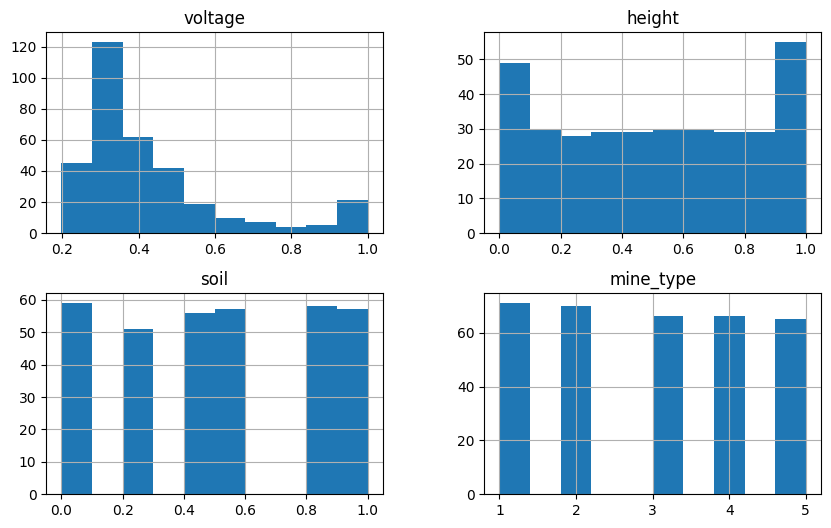

In [12]:
#1 Cleaning the data & EDA
df.head()
print("shape:", df.shape)
print(df.isna().sum())
print('\n', df["mine_type"].value_counts())
print('\n', df.groupby("mine_type").mean())
df.hist(figsize=(10,6))
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

In [13]:
#2
X = df[["voltage", "height", "soil"]].copy()
y = df["mine_type"]
X["voltage"] = X["voltage"] * 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42)

Best k: 1


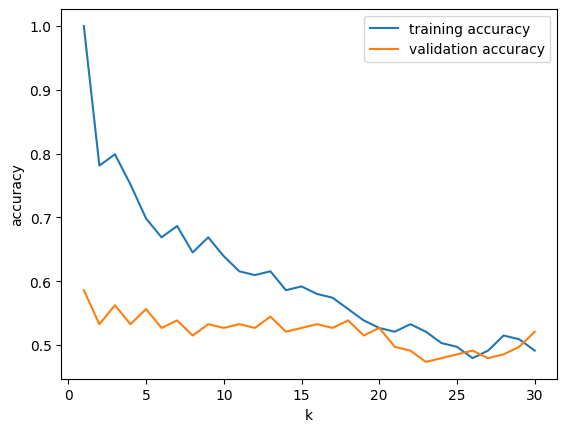

In [16]:
#3
ks = range(1, 31)
train_acc, valid_acc = [], []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    valid_acc.append(model.score(X_test, y_test))
best_k = ks[valid_acc.index(max(valid_acc))]
print("Best k:", best_k)
plt.plot(ks, train_acc, label="training accuracy")
plt.plot(ks, valid_acc, label="validation accuracy")
plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend()
plt.show()

'''
I chose k by fitting a k-NN classifier on the training half for each k from 1 to 30, computing
its accuracy on the validation half, and selecting the k with the highest validation accuracy,
which was k = 1 (0.586). I didn't use training accuracy because it favors very small k
(k = 1 scores 100% on its own training data) and can overfit noise, while very large k
underfits by predicting nearly the same class everywhere. Validation accuracy was highest at
small k and generally declined as k grew, reflecting the narrow voltage differences between
mine types, though another split might give a different best k.
'''

In [17]:
#4
model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
y_pred = model.predict(X_test)
print(pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"]))
print("Accuracy:", accuracy_score(y_test, y_pred))

predicted   1   2   3   4   5
actual                       
1          27   0   2   0   7
2           0  32   1   2   0
3           4   2  11   7   9
4           3   5   6  15   4
5           4   0   7   7  14
Accuracy: 0.5857988165680473


Even though the model gbets 59% of mines right overall, and does very well on some types, I wouldn't advise anyone to rely on it alone. The confusion matrix shows why, because it is good at pikcing out type 2 mines (32 out of 35 correct) and decent with type 1, but it really struggles to differentiate between types 3,4, and 5. Accuracy treats every mistake as equally bad, and in this setting they clearly aren't. Mixing up two kinds of mines is much less serious than predicting type 1 (which is no mine) for something that is actually a mine, and the model did that *11 times*. Someone that's walking into a mine field and trusting this model could be killed very easily with these mistakes.

So if I was going to tell people how to use this model, I would recommend them use this model as a preliminary guess, and if it predicts type 3,4, or 5, to definitely treat it as "Mine here, but not sure what kind". A type 1 prediction should not be used to definitely say that an area is safe, and every location should still definitely be cleared in the same way. It would also help to use a larger k values and look at the share of neighbors that are each class, instead of only the single most common one. If even a few neighbors are mines, the location should be treated with caution.

Last but not least, I would also be very up front with anyone using this data about the dataset and training data.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]